# Jacobi iteration and conjugate gradient

We study two iterative methods for solving the linear system

$$
Ax=b.
$$

The emphasis here is geometric and algorithmic.

Jacobi iteration is a stationary method. It is simple, cheap per step, and easy to analyze.

Conjugate gradient is a Krylov method for symmetric positive definite systems. It uses the geometry induced by $A$ much more effectively.

The goal of this notebook is not full generality. The goal is to build the core picture carefully.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Why iterative methods?

A direct method tries to solve the system in a finite sequence of eliminations.

An iterative method starts from an initial guess $x^{(0)}$ and produces a sequence

$$
x^{(0)},x^{(1)},x^{(2)},\dots
$$

that, one hopes, approaches the exact solution $x_\ast$.

This is useful when $A$ is large and sparse. In that setting, one matrix-vector product can be cheap, while a full factorization may be expensive.


## Jacobi iteration

Write $A$ as

$$
A=D+(L+U),
$$

where $D$ is the diagonal of $A$, $L$ is the strict lower triangular part, and $U$ is the strict upper triangular part.

From $Ax=b$ we obtain

$$
Dx=b-(L+U)x.
$$

This suggests the iteration

$$
x^{(k+1)} = D^{-1}\bigl(b-(L+U)x^{(k)}\bigr).
$$

Each component update uses the old iterate on the right-hand side. So Jacobi is fully parallel across components, but it only uses diagonal solves.


## Error propagation for Jacobi

Let $x_\ast$ be the exact solution and define the error $e^{(k)}=x^{(k)}-x_\ast$.

Subtracting the fixed-point equation for $x_\ast$ from the iteration gives

$$
e^{(k+1)} = -D^{-1}(L+U)e^{(k)}.
$$

The matrix

$$
T_J = -D^{-1}(L+U)
$$

is the Jacobi iteration matrix.

Jacobi converges for every initial guess if the powers of $T_J$ decay to zero. A standard criterion is

$$
\rho(T_J)<1,
$$

where $\rho(\cdot)$ is the spectral radius.

So the method is controlled by how strongly the off-diagonal couplings compete with the diagonal.


## A first geometric picture

For a $2\times 2$ system, each row of $Ax=b$ defines a line.

The exact solution is the intersection point.

Jacobi updates one component using the previous value of the other. Geometrically, this often produces a zig-zag path toward the intersection.


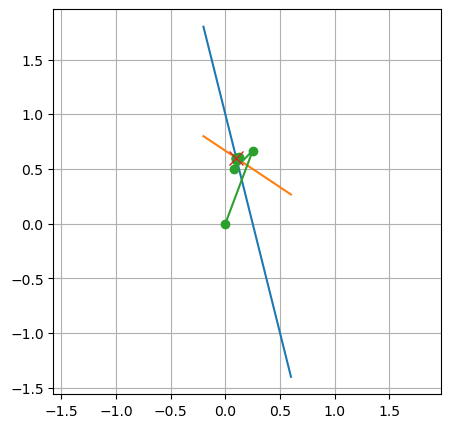

In [2]:
A = np.array([[4., 1.],
              [2., 3.]])
b = np.array([1., 2.])

def jacobi(A, b, x0, steps):
    D = np.diag(np.diag(A))
    R = A - D
    x = x0.astype(float).copy()
    xs = [x.copy()]
    for _ in range(steps):
        x = np.linalg.solve(D, b - R @ x)
        xs.append(x.copy())
    return np.array(xs)

xs = jacobi(A, b, np.array([0., 0.]), 8)
xstar = np.linalg.solve(A, b)

x1 = np.linspace(-0.2, 0.6, 200)
x2_line1 = 1 - 4*x1
x2_line2 = (2 - 2*x1)/3

plt.figure(figsize=(5,5))
plt.plot(x1, x2_line1)
plt.plot(x1, x2_line2)
plt.plot(xs[:,0], xs[:,1], 'o-')
plt.plot(xstar[0], xstar[1], 'x', markersize=10)
plt.axis('equal')
plt.grid(True)
plt.show()


The path is not arbitrary. It is generated by repeated action of the iteration matrix $T_J$ on the error.

When the spectral radius is comfortably below $1$, the zig-zag contracts.

When it is not, the method can stagnate or diverge.


## A standard sufficient condition

A common sufficient condition for Jacobi convergence is strict diagonal dominance:

$$
|a_{ii}| > \sum_{j\neq i} |a_{ij}| \qquad \text{for every } i.
$$

This condition is not necessary, but it gives a clear structural interpretation.

If the diagonal dominates, then each variable is controlled mainly by its own equation, and the off-diagonal couplings act as a perturbation rather than the main effect.


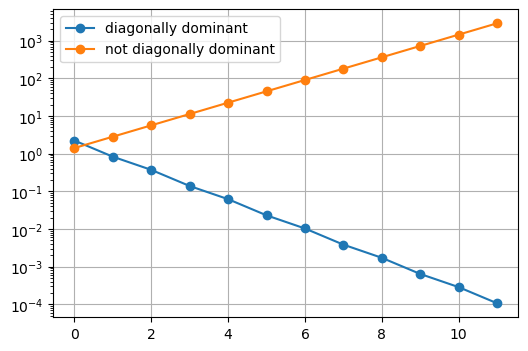

In [3]:
A1 = np.array([[4., 1.],
               [2., 3.]])
b1 = np.array([1., 2.])

A2 = np.array([[1., 2.],
               [2., 1.]])
b2 = np.array([1., 1.])

def jacobi_residuals(A, b, steps):
    x = np.zeros_like(b, dtype=float)
    D = np.diag(np.diag(A))
    R = A - D
    vals = []
    for _ in range(steps):
        vals.append(np.linalg.norm(b - A @ x))
        x = np.linalg.solve(D, b - R @ x)
    return vals

r1 = jacobi_residuals(A1, b1, 12)
r2 = jacobi_residuals(A2, b2, 12)

plt.figure(figsize=(6,4))
plt.semilogy(r1, 'o-', label='diagonally dominant')
plt.semilogy(r2, 'o-', label='not diagonally dominant')
plt.legend()
plt.grid(True)
plt.show()


The second system exhibits a failure mode.

The method is cheap because it ignores most of the coupling during each update. That same simplification is exactly why it can fail.


## Residual and error

The residual at step $k$ is

$$
r^{(k)} = b-Ax^{(k)}.
$$

It measures how well the current iterate satisfies the equation.

The error is

$$
e^{(k)} = x^{(k)}-x_\ast.
$$

These are related by

$$
r^{(k)} = -Ae^{(k)}.
$$

So a small error implies a small residual, but the converse depends on conditioning. If $A$ is ill-conditioned, residual and error can differ significantly in scale.


## Conjugate gradient

Now assume that $A$ is symmetric positive definite.

Then solving $Ax=b$ is equivalent to minimizing the quadratic functional

$$
\phi(x)=\frac12 x^T A x - b^T x.
$$

Its gradient is

$$
\nabla \phi(x)=Ax-b.
$$

So the solution is the unique minimizer of a strictly convex quadratic.

Conjugate gradient exploits this structure. It does not merely descend. It builds search directions that are mutually $A$-orthogonal.


## Why the quadratic picture matters

For symmetric positive definite $A$, the level sets of $\phi$ are ellipses in two dimensions.

Gradient descent moves orthogonally to the level sets in the Euclidean metric. This can lead to slow zig-zag motion.

Conjugate gradient instead chooses directions that are conjugate with respect to $A$:

$$
p_i^T A p_j = 0 \qquad \text{for } i\neq j.
$$

This prevents the method from undoing progress made in earlier directions.


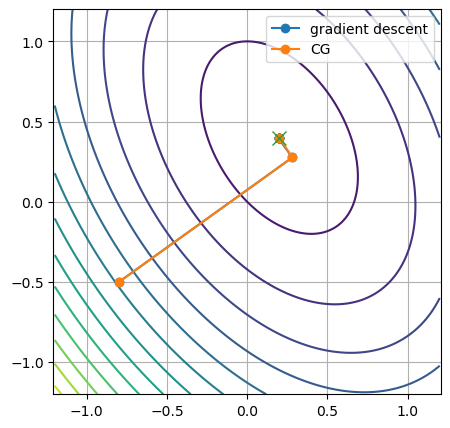

In [4]:
A = np.array([[3., 1.],
              [1., 2.]])
b = np.array([1., 1.])

def grad_descent(A, b, x0, steps):
    x = x0.astype(float).copy()
    xs = [x.copy()]
    for _ in range(steps):
        r = b - A @ x
        alpha = (r @ r) / (r @ A @ r)
        x = x + alpha * r
        xs.append(x.copy())
    return np.array(xs)

def cg(A, b, x0, steps):
    x = x0.astype(float).copy()
    r = b - A @ x
    p = r.copy()
    xs = [x.copy()]
    for _ in range(steps):
        alpha = (r @ r) / (p @ A @ p)
        x = x + alpha * p
        r_new = r - alpha * (A @ p)
        xs.append(x.copy())
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new
    return np.array(xs)

gd = grad_descent(A, b, np.array([-0.8, -0.5]), 6)
cg_pts = cg(A, b, np.array([-0.8, -0.5]), 2)
xstar = np.linalg.solve(A, b)

x = np.linspace(-1.2, 1.2, 200)
y = np.linspace(-1.2, 1.2, 200)
X, Y = np.meshgrid(x, y)
Z = 0.5*(A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2) - b[0]*X - b[1]*Y

plt.figure(figsize=(5,5))
plt.contour(X, Y, Z, levels=12)
plt.plot(gd[:,0], gd[:,1], 'o-', label='gradient descent')
plt.plot(cg_pts[:,0], cg_pts[:,1], 'o-', label='CG')
plt.plot(xstar[0], xstar[1], 'x', markersize=10)
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


In exact arithmetic, conjugate gradient solves an $n\times n$ symmetric positive definite problem in at most $n$ steps.

That statement is algebraic, not asymptotic. The method searches in the Krylov spaces

$$
\mathcal K_k(A,r_0)=\mathrm{span}\{r_0,Ar_0,\dots,A^{k-1}r_0\}.
$$

At step $k$, CG selects the best point in $x_0+\mathcal K_k(A,r_0)$ with respect to the $A$-norm of the error.


## The basic CG recurrences

Starting from $x_0$, define

$$
r_0=b-Ax_0, \qquad p_0=r_0.
$$

Then for $k=0,1,2,\dots$,

$$
\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k},
$$

$$
x_{k+1}=x_k+\alpha_k p_k,
$$

$$
r_{k+1}=r_k-\alpha_k A p_k,
$$

$$
\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k},
$$

$$
p_{k+1}=r_{k+1}+\beta_k p_k.
$$

The formula is short, but the geometry is strong. Residuals become mutually orthogonal, and search directions become mutually $A$-orthogonal.


In [5]:
A = np.array([[4., 1.],
              [1., 3.]])
b = np.array([1., 2.])

x = np.zeros(2)
r = b - A @ x
p = r.copy()

for k in range(4):
    alpha = (r @ r) / (p @ A @ p)
    x = x + alpha * p
    r_new = r - alpha * (A @ p)
    print("k =", k, "||r|| =", np.linalg.norm(r_new))
    beta = (r_new @ r_new) / (r @ r)
    p = r_new + beta * p
    r = r_new


k = 0 ||r|| = 0.5590169943749475
k = 1 ||r|| = 0.0
k = 2 ||r|| = nan
k = 3 ||r|| = nan


/var/folders/c7/56zb_b0d5ljcc_czr527c01w0000gn/T/ipykernel_18289/426306226.py:10: RuntimeWarning: invalid value encountered in scalar divide
  alpha = (r @ r) / (p @ A @ p)


## A larger model problem

We now compare the two methods on the tridiagonal matrix

$$
A =
\begin{bmatrix}
2 & -1 \\
-1 & 2 & -1 \\
& \ddots & \ddots & \ddots \\
&& -1 & 2
\end{bmatrix}.
$$

This matrix is symmetric positive definite. It is a standard finite-difference model for the one-dimensional Poisson operator.

So both Jacobi and conjugate gradient apply, but their convergence behavior is very different.


/var/folders/c7/56zb_b0d5ljcc_czr527c01w0000gn/T/ipykernel_18289/124652290.py:22: RuntimeWarning: invalid value encountered in scalar divide
  alpha = (r @ r) / (p @ A @ p)


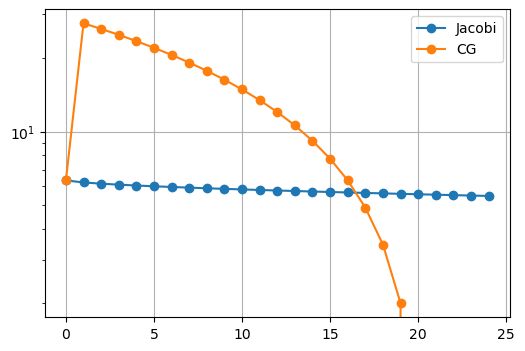

In [6]:
n = 40
A = 2*np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)
b = np.ones(n)

def jacobi_res(A, b, steps):
    x = np.zeros_like(b)
    D = np.diag(np.diag(A))
    R = A - D
    vals = []
    for _ in range(steps):
        vals.append(np.linalg.norm(b - A @ x))
        x = np.linalg.solve(D, b - R @ x)
    return vals

def cg_res(A, b, steps):
    x = np.zeros_like(b)
    r = b - A @ x
    p = r.copy()
    vals = []
    for _ in range(steps):
        vals.append(np.linalg.norm(r))
        alpha = (r @ r) / (p @ A @ p)
        x = x + alpha * p
        r_new = r - alpha * (A @ p)
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new
    return vals

jr = jacobi_res(A, b, 25)
cr = cg_res(A, b, 25)

plt.figure(figsize=(6,4))
plt.semilogy(jr, 'o-', label='Jacobi')
plt.semilogy(cr, 'o-', label='CG')
plt.legend()
plt.grid(True)
plt.show()


The contrast is the main point.

Jacobi uses only diagonal information, so its progress is local and limited.

CG uses the full operator through matrix-vector products and exploits the symmetric positive definite structure globally.


## Conditioning still matters

Even for CG, conditioning matters.

For symmetric positive definite $A$, the condition number in the Euclidean norm is

$$
\kappa(A)=\frac{\lambda_{\max}(A)}{\lambda_{\min}(A)}.
$$

A large spread in eigenvalues leads to stretched level sets of the quadratic, which makes iterative progress harder.

A standard bound for CG is

$$
\|e_k\|_A \leq 2
\left(
\frac{\sqrt{\kappa(A)}-1}{\sqrt{\kappa(A)}+1}
\right)^k
\|e_0\|_A.
$$

So the square root of the condition number appears directly in the convergence estimate.


In [7]:
ns = [10, 20, 40, 80]
conds = []

for n in ns:
    A = 2*np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)
    conds.append(np.linalg.cond(A))

conds


[48.37415007870824, 178.06427461086028, 680.6170700217061, 2658.4065019157874]

For this model problem, the condition number grows with $n$.

So a sparse structured matrix can still become harder as the dimension increases. This is one reason preconditioning is central in practice.


## Final comparison

Jacobi iteration is a simple stationary fixed-point method. Its cost per step is very low, but convergence can be slow or can fail.

Conjugate gradient is a Krylov method for symmetric positive definite systems. It is still inexpensive per step for sparse matrices, but it uses the geometry of the problem far more effectively.

So the distinction is not merely speed. The distinction is how much of the operator each method uses at every iteration.
